欢迎来到上海交通大学 CS7353（2025年春季学期）《[设计和理解深度神经网络](https://cs7353.netlify.app/)》！

这里是第四次课程作业，具体时间信息见[课程网站](https://cs7353.netlify.app/)。作业在 Canvas 上提交，注意时间节点。只需要上传一份 ipynb 文件，请务必保留每个单元格的运行结果。

如有任何问题，请联系[助教](https://cs7353.netlify.app/staff/)。

# 1 简介

在本次作业中，您将实现[Vision Transformer（ViT）](https://arxiv.org/abs/2010.11929)和[Masked Autoencoder（MAE）](https://arxiv.org/abs/2111.06377)。


注意，请严格遵守以下注意事项，如有违背，本次作业零分处理：
- 请在标明的 BEGIN YOUR CODE 位置完成代码，或者可以调节训练时optimizer参数，此外请勿更改其他代码；
- 请勿 import 其他 python package（补充：请手搓，不要为了省事直接调用打包好的函数）；
- 请务必保留每个单元格的运行结果。

# 2 准备

我们建议在启用GPU的Colab上进行工作，因为这个任务需要相当大量的计算资源。
在Colab中，我们可以通过点击`运行时 -> 更改运行时类型 -> 硬件加速器`，然后选择`GPU`来强制使用GPU。

请注意，每日[Colab 有用量限额](https://research.google.com/colaboratory/faq.html#usage-limits)，如用完，可以等待第二日额度更新，或者升级到Colab Pro。
Colab 之所以能够免费提供资源，部分原因在于它的用量限额是时有变化的动态限额，并且它不会保证资源供应或无限供应资源。也就是说，总体用量限额、空闲超时时长、虚拟机生命周期上限、可用 GPU 类型以及其他因素都会不时变化。Colab 不会公布这些限额，原因之一是它们可能会随着时间变化。


一旦笔记本被执行，依赖项将会被安装。
您应该将此笔记本复制到您的 Google Drive 中，否则输出将不会被保存。
一旦文件夹被复制，您可以通过点击Jupyter笔记本并在Colab中打开它来开始工作。

## 2.1 准备GPU

In [ ]:
!nvidia-smi # Confirm GPU is enabled

Wed Jun 11 05:36:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

装载 Google Drive，建议登录与 Colab 相同的 Google 账号。

In [ ]:
# Mount drive to save models and logs
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


注意：将root_folder更改为此笔记本在您的 Google Drive中的文件夹

In [ ]:
import os
root_folder = "/content/drive/MyDrive/cs7353_hw4_colab/"
os.makedirs(root_folder, exist_ok=True)
os.chdir(root_folder)

## 2.2 下载数据集


In [ ]:
!pip install gdown
!gdown --fuzzy -O '/content/test_reference.pt' 'https://drive.google.com/file/d/1rwSf45WsmadCqFZB9n83Nlc5OfrUap3j/view?usp=sharing'
!pip -q install einops

import torch
test_data = torch.load('/content/test_reference.pt')

Downloading...
From (original): https://drive.google.com/uc?id=1rwSf45WsmadCqFZB9n83Nlc5OfrUap3j
From (redirected): https://drive.google.com/uc?id=1rwSf45WsmadCqFZB9n83Nlc5OfrUap3j&confirm=t&uuid=5778b71b-b3b7-41c6-94c7-212eead977d1
To: /content/test_reference.pt
100% 46.0M/46.0M [00:01<00:00, 38.6MB/s]


## 2.3 辅助函数

这里是辅助函数，**您不必进行任何代码层面的操作**，仅需运行对应单元格。

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn
seaborn.set()

from tqdm.notebook import trange, tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import einops
import pickle
import os

torch_device = 'cuda' if torch.cuda.is_available() else 'cpu'

def rel_error(x, y):
    return torch.max(
        torch.abs(x - y)
        / (torch.maximum(torch.tensor(1e-8), torch.abs(x) + torch.abs(y)))
    ).item()

def check_error(name, x, y):
    error = rel_error(x, y)
    print(f"{name}'s relative error:  {error}")

def check_acc(acc, threshold):
    print(f'The accuracy:  {acc} (error: {max(0.0, threshold-acc)})')

#3 Vision Transformer
实现 Vision Transformer（ViT） 并在 CIFAR 数据集上对其进行训练。

## 3.1 图像 patchify 和 unpatchify

在ViT中，图像被分割成固定大小的patch，然后每个patch都被线性嵌入，加上position embedding，最终的向量序列被送入标准的Transformer编码器。该架构如下图所示。

![vit](https://github.com/google-research/vision_transformer/blob/main/vit_figure.png?raw=true)

### 3.1.1 代码

要开始实现ViT，您需要在`patchify`中实现将 image batch 拆分为固定大小的 patch batch，并在`unpatchify`中将 patch batch组合成原始 image batch。您仅需要考虑长宽一致的情况，因而可以通过``images``传递尺寸等相关信息。

我们强烈建议使用[einops](https://github.com/arogozhnikov/einops)进行灵活的张量操作，您可以查看它的[tutorial](https://einops.rocks/1-einops-basics/)。

In [ ]:
def patchify(images, patch_size=4):
    """Splitting images into patches.
    Args:
        images: Input tensor with size (batch, channels, height, width)
            We can assume that image is square where height == width.
    Returns:
        A batch of image patches with size (
          batch, (height / patch_size) * (width / patch_size),
        channels * patch_size * patch_size)
    """
    # BEGIN YOUR CODE
    patches = einops.rearrange(images, 'b c (h p1) (w p2) -> b (h w) (c p1 p2)', p1=patch_size, p2=patch_size)
    return patches
    # END YOUR CODE

def unpatchify(patches, patch_size=4):
    """Combining patches into images.
    Args:
        patches: Input tensor with size (
        batch, (height / patch_size) * (width / patch_size),
        channels * patch_size * patch_size)
    Returns:
        A batch of images with size (batch, channels, height, width)
    """
    # BEGIN YOUR CODE
    patches_per_side = int(np.sqrt(patches.shape[1]))
    images = einops.rearrange(patches, 'b (h w) (c p1 p2) -> b c (h p1) (w p2)', p1=patch_size, p2=patch_size, h = patches_per_side)
    return images
    # END YOUR CODE

### 3.1.2 测试

完成后，运行以下代码以检查您的实现。您应该看到误差为 ``0.0``。

In [ ]:
x = test_data['input']['patchify']
y = test_data['output']['patchify']
check_error('patchify', patchify(x), y)

x = test_data['input']['unpatchify']
y = test_data['output']['unpatchify']
check_error('unpatchify', unpatchify(x), y)

patchify's relative error:  0.0
unpatchify's relative error:  0.0


## 3.2 ViT 模型



### 3.2.1 代码

您需要使用给定的Transformer编码器```Transformer```来在```ViT```和```ClassificationViT```中实现ViT。

In [ ]:
class Transformer(nn.Module):
    """Transformer Encoder
    Args:
        embedding_dim: dimension of embedding
        n_heads: number of attention heads
        n_layers: number of attention layers
        feedforward_dim: hidden dimension of MLP layer
    Returns:
        Transformer embedding of input
    """
    def __init__(self, embedding_dim=256, n_heads=4, n_layers=4, feedforward_dim=1024):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.feedforward_dim = feedforward_dim
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=embedding_dim,
                nhead=self.n_heads,
                dim_feedforward=self.feedforward_dim,
                activation=F.gelu,
                batch_first=True,
                dropout=0.0,
            ),
            num_layers=n_layers,
        )

    def forward(self, x):
        return self.transformer(x)

class ClassificationViT(nn.Module):
    """Vision transformer for classfication
    Args:
        n_classes: number of classes
        embedding_dim: dimension of embedding
        patch_size: image patch size
        num_patches: number of image patches
    Returns:
        Logits of classfication
    """
    def __init__(self, n_classes, embedding_dim=256, patch_size=4, num_patches=8):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.embedding_dim = embedding_dim

        self.transformer = Transformer(embedding_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.02)
        self.position_encoding = nn.Parameter(
            torch.randn(1, num_patches * num_patches + 1, embedding_dim) * 0.02
        )
        self.patch_projection = nn.Linear(patch_size * patch_size * 3, embedding_dim)

        # A Layernorm and a Linear layer are applied on ViT encoder embeddings
        self.output_head = nn.Sequential(
            nn.LayerNorm(embedding_dim), nn.Linear(embedding_dim, n_classes)
        )

    def forward(self, images):
        """
        (1) Splitting images into fixed-size patches;
        (2) Linearly embed each image patch, append CLS token;
        (3) Add position embeddings;
        (4) Feed the resulting sequence of vectors to Transformer encoder.
        (5) Extract the embeddings corresponding to the CLS token.
        (6) Apply output head to the embeddings to obtain the logits
        """
        # BEGIN YOUR CODE
        # patchify
        patches = patchify(images)

        # embed patches to embedding dim
        patches = self.patch_projection(patches)

        # append cls token
        batch_size = images.shape[0]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, patches), dim=1)

        # add position embeddings
        input = x + self.position_encoding # automatic broadcasting

        # feed the result sequence to Transformer encoder
        output = self.transformer(input)

        # extract cls token
        class_out = output[:, 0]

        # obtain the logits
        logits = self.output_head(class_out)

        return logits
        # END YOUR CODE

### 3.2.2 测试

完成后，运行以下代码以检查您的实现。您应该看到误差小于 ``1e-4``。

In [ ]:
model = ClassificationViT(10)
model.load_state_dict(test_data['weights']['ClassificationViT'])
x = test_data['input']['ClassificationViT.forward']
y = model.forward(x)
check_error('ClassificationViT.forward', y, test_data['output']['ClassificationViT.forward'])

ClassificationViT.forward's relative error:  1.3554922588809859e-05


## 3.3 训练 ViT

### 3.3.1 数据集和预处理
我们使用```torchvision```来下载和准备图像和标签。

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.Resize(32),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='/content/data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='/content/data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:12<00:00, 13.1MB/s]


### 3.3.2 有监督学习

你可以选择调整这些超参数以获得更好的性能，也可以不做更改。


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

...

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Val Accuracy')

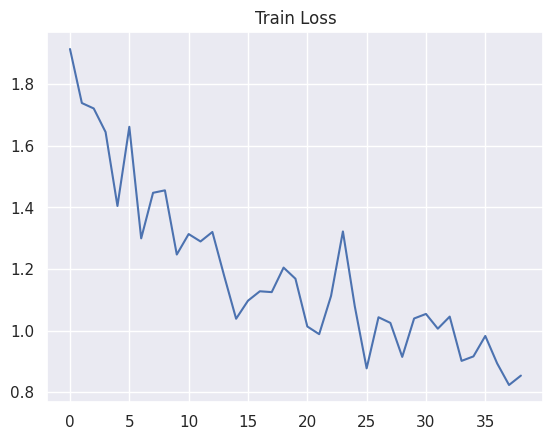

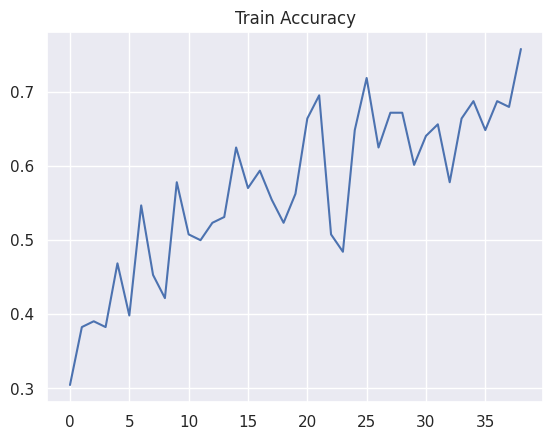

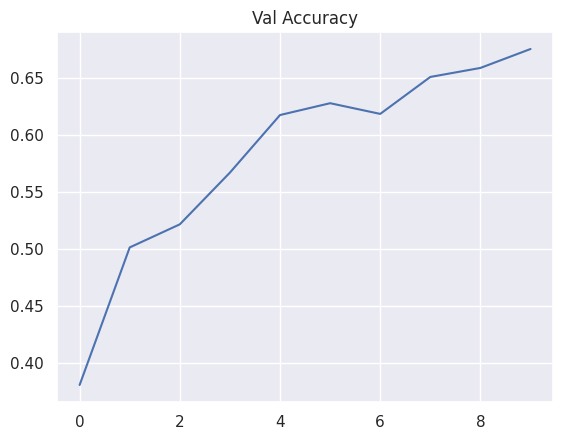

In [ ]:
# Initilize model (ClassificationViT)
model = ClassificationViT(10)
# Move model to GPU
model.to(torch_device)
# Create optimizer for the model

# You may want to tune these hyperparameters to get better performance
optimizer = optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.95), weight_decay=1e-9)

total_steps = 0
num_epochs = 10
train_logfreq = 100
losses = []
train_acc = []
all_val_acc = []
best_val_acc = 0

epoch_iterator = trange(num_epochs)
for epoch in epoch_iterator:
    # Train
    data_iterator = tqdm(trainloader)
    for x, y in data_iterator:
        total_steps += 1
        x, y = x.to(torch_device), y.to(torch_device)
        logits = model(x)
        loss = torch.mean(F.cross_entropy(logits, y))
        accuracy = torch.mean((torch.argmax(logits, dim=-1) == y).float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        data_iterator.set_postfix(loss=loss.item(), train_acc=accuracy.item())

        if total_steps % train_logfreq == 0:
            losses.append(loss.item())
            train_acc.append(accuracy.item())

    # Validation
    val_acc = []
    model.eval()
    for x, y in testloader:
        x, y = x.to(torch_device), y.to(torch_device)
        with torch.no_grad():
          logits = model(x)
        accuracy = torch.mean((torch.argmax(logits, dim=-1) == y).float())
        val_acc.append(accuracy.item())
    model.train()

    all_val_acc.append(np.mean(val_acc))
    # Save best model
    if np.mean(val_acc) > best_val_acc:
        best_val_acc = np.mean(val_acc)

    epoch_iterator.set_postfix(val_acc=np.mean(val_acc), best_val_acc=best_val_acc)

plt.plot(losses)
plt.title('Train Loss')
plt.figure()
plt.plot(train_acc)
plt.title('Train Accuracy')
plt.figure()
plt.plot(all_val_acc)
plt.title('Val Accuracy')

### 3.3.3 测试

完成后，运行以下代码以检查您的实现。您应该看到准确率大于 ``65%``。

In [ ]:
check_acc(best_val_acc, threshold=0.65)

The accuracy:  0.6754351265822784 (error: 0.0)


# 4 Masked AutoEncoder
这个作业的第二部分是实现 Masked Autoencoder（MAE）。
MAE的想法是遮蔽输入图像的随机补丁并重建缺失的像素。整个架构如下图所示。

![mae](https://user-images.githubusercontent.com/11435359/146857310-f258c86c-fde6-48e8-9cee-badd2b21bd2c.png)


您将在 CIFAR 上无标签地训练MAE，也就是自监督学习。
然后，您将使用自监督预训练模型进行线性分类和微调实验。


## 4.1 Random Masking 和 Restore


MAE (Masked Autoencoder) 是一种用于自动编码的神经网络结构，Random Masking 和 Restore 是其中一种常见的技术。

在 MAE 中，Random Masking 和 Restore 通常用于训练过程中的数据处理。其基本思想是在输入数据中随机遮盖（或屏蔽）一些部分，然后尝试从部分遮盖的数据中重建原始数据。这种遮盖的过程可以被视为一种噪声注入，有助于网络学习到更鲁棒的特征。

具体地说，Random Masking 和 Restore 通常包括以下步骤：

1. **随机遮盖（Random Masking）**：在输入数据中随机选择一些位置，并将它们的值替换为特定的遮盖标记（比如0）。这样就生成了部分遮盖的输入数据。

2. **重建（Restore）**：使用遮盖后的数据作为输入，训练网络尝试重建原始数据。这个过程要求网络不仅学会提取数据中的有用特征，还需要学会对遮盖的部分进行恢复，使得重建的结果尽可能接近原始数据。

通过 Random Masking 和 Restore，MAE 能够学习到对输入数据的部分遮盖具有鲁棒性的表示，并且能够在一定程度上提高模型的泛化能力。这种技术在处理缺失数据、噪声数据或者对抗性攻击等方面都有着一定的应用潜力。

### 4.1.1 代码

要开始使用 MAE，您需要实现```random_masking```来从输入图像中遮蔽随机 patch，并且实现```restore_masked```来将重建的遮蔽部分和未遮蔽部分组合起来恢复图像。

In [ ]:
def index_sequence(x, ids):
    """Index tensor (x) with indices given by ids
    Args:
        x: input sequence tensor, can be 2D (batch x length) or 3D (batch x length x feature)
        ids: 2D indices (batch x length) for re-indexing the sequence tensor
    """
    if len(x.shape) == 3:
        ids = ids.unsqueeze(-1).expand(-1, -1, x.shape[-1])
    return torch.take_along_dim(x, ids, dim=1)

def random_masking(x, keep_length, ids_shuffle):
    """Apply random masking on input tensor
    Args:
        x: input patches (batch x length x feature)
        keep_length: length of unmasked patches
        ids_shuffle: random indices for shuffling the input sequence
    Returns:
        kept: unmasked part of x
        mask: a 2D (batch x length) mask tensor of 0s and 1s indicated which
            part of x is masked out. The value 0 indicates not masked and 1
            indicates masked.
        ids_restore: indices to restore x. If we take the kept part and masked
            part of x, concatentate them together and index it with ids_restore,
            we should get x back.

    Hint:
        ids_shuffle contains the indices used to shuffle the sequence (patches).
        You should use the provided index_sequence function to re-index the
        sequence, and keep the first keep_length number of patches.
    """
    # BEGIN YOUR CODE
    x_shuffled = index_sequence(x, ids_shuffle)
    kept = x_shuffled[:, :keep_length]
    batch_size, seq_length, _ = x.shape
    mask_shuffled = torch.ones(batch_size, seq_length, device = x.device)
    mask_shuffled[:, :keep_length] = 0

    ids_restore = torch.argsort(ids_shuffle, dim=1)
    mask = torch.gather(mask_shuffled, dim = 1, index = ids_restore)

    return kept, mask, ids_restore
    # END YOUR CODE

def restore_masked(kept_x, masked_x, ids_restore):
    """Restore masked patches
    Args:
        kept_x: unmasked patches
        masked_x: masked patches
        ids_restore: indices to restore x
    Returns:
        restored patches
    """
    # BEGIN YOUR CODE
    x = torch.cat([kept_x, masked_x], dim=1)
    restored = index_sequence(x, ids_restore)
    return restored
    # END YOUR CODE

### 4.1.2 测试
完成后，运行以下代码以检查您的实现。您应该看到误差为 ``0.0``。

In [ ]:
x, ids_shuffle = test_data['input']['random_masking']
kept, mask, ids_restore = random_masking(x, 4, ids_shuffle)
kept_t, mask_t, ids_restore_t = test_data['output']['random_masking']
check_error('random_masking: kept', kept, kept_t)
check_error('random_masking: mask', mask, mask_t)
check_error('random_masking: ids_restore', ids_restore, ids_restore_t)

kept_x, masked_x, ids_restore = test_data['input']['restore_masked']
restored = restore_masked(kept_x, masked_x, ids_restore)
check_error('restore_masked', restored, test_data['output']['restore_masked'])

random_masking: kept's relative error:  0.0
random_masking: mask's relative error:  0.0
random_masking: ids_restore's relative error:  0.0
restore_masked's relative error:  0.0


## 4.2 MAE AutoEncoder

MAE (Masked Autoencoder) Autoencoder 是一种特殊类型的自动编码器，旨在通过无监督学习的方式学习数据的有效表示，同时具备一定的鲁棒性和泛化能力。

MAE Autoencoder 与传统的自动编码器有所不同，其主要特点在于引入了遮盖（Masking）机制，这使得网络在训练过程中需要处理部分遮盖的输入数据，并尝试从中恢复原始数据。这种遮盖的过程通常通过随机遮盖一部分输入数据来实现。

MAE Autoencoder 通常包括两个主要组件：

1. **Encoder**：负责将输入数据编码为一个低维的表示，其中包含了输入数据的关键特征。在 MAE 中，Encoder 通过学习如何提取数据的有用特征，并将其映射到一个紧凑的表示空间中。

2. **Decoder**：与 Encoder 相对应，Decoder 负责将编码后的低维表示解码为重建的输入数据。在 MAE 中，Decoder 的任务是尽可能准确地从编码表示中重建原始数据，同时对部分遮盖的输入数据进行恢复。

MAE Autoencoder 的训练过程通常通过最小化重建误差来实现，即网络的输出与输入数据之间的差异。通过不断地调整 Encoder 和 Decoder 的参数，使得网络能够学习到更好的编码和解码策略，从而得到更好的重建结果。

### 4.2.1 代码

In [ ]:
class MaskedAutoEncoder(nn.Module):
    """MAE Encoder
    Args:
        encoder: vit encoder
        decoder: vit decoder
        encoder_embedding_dim: embedding size of encoder
        decoder_embedding_dim: embedding size of decoder
        patch_size: image patch size
        num_patches: number of patches
        mask_ratio: percentage of masked patches
    """
    def __init__(self, encoder, decoder, encoder_embedding_dim=256,
                 decoder_embedding_dim=128, patch_size=4, num_patches=8,
                 mask_ratio=0.75):
        super().__init__()
        self.encoder_embedding_dim = encoder_embedding_dim
        self.decoder_embedding_dim = decoder_embedding_dim
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.mask_ratio = mask_ratio

        self.masked_length = int(num_patches * num_patches * mask_ratio)
        self.keep_length = num_patches * num_patches - self.masked_length

        self.encoder = encoder
        self.decoder = decoder

        self.encoder_input_projection = nn.Linear(patch_size * patch_size * 3, encoder_embedding_dim)
        self.decoder_input_projection = nn.Linear(encoder_embedding_dim, decoder_embedding_dim)
        self.decoder_output_projection = nn.Linear(decoder_embedding_dim, patch_size * patch_size * 3)
        self.cls_token = nn.Parameter(torch.randn(1, 1, encoder_embedding_dim) * 0.02)
        self.encoder_position_encoding = nn.Parameter(torch.randn(1, num_patches * num_patches, encoder_embedding_dim) * 0.02)
        self.decoder_position_encoding = nn.Parameter(torch.randn(1, num_patches * num_patches, decoder_embedding_dim) * 0.02)
        self.masked_tokens = nn.Parameter(torch.randn(1, 1, decoder_embedding_dim) * 0.02)

    def forward_encoder(self, images, ids_shuffle=None):
        """Encode input images
        You should implement the following steps
        (1) patchify images into patches
        (2) linear projection
        (3) add position encoding
        (4) concatenate cls_token and patches embedding and pass it to vit encoder
        """
        batch_size = images.shape[0]
        # Generate random shuffling indices
        if ids_shuffle is None:
            ids_shuffle = torch.argsort(
                torch.rand(
                    (batch_size, self.num_patches * self.num_patches),
                    device=images.device
                ),
                dim=1
            )
        # BEGIN YOUR CODE
        patches = patchify(images)
        patches = self.encoder_input_projection(patches)
        patches = patches + self.encoder_position_encoding
        patches_visible, mask, ids_restore = random_masking(patches, self.keep_length, ids_shuffle)

        cls_tokens = self.cls_token.expand(batch_size, 1, -1)
        x = torch.cat([cls_tokens, patches_visible], dim=1)
        encoder_embeddings = self.encoder(x)

        return encoder_embeddings, mask, ids_restore
        # END YOUR CODE

    def forward_decoder(self, encoder_embeddings, ids_restore):
        """Decode encoder embeddings
        You should implement the following steps
        (1) linear projection of encoder embeddings
        (2) restore sequence from masked_patches and encoder predictions
        (3) add position encoding
        (3) readd/use CLS token and decode using ViT decoder
        (4) projection to predict image patches
        """
        # BEGIN YOUR CODE
        batch_size = encoder_embeddings.shape[0]
        encoder_patches = encoder_embeddings[:,1:,:]
        decoded = self.decoder_input_projection(encoder_patches)

        mask_tokens = self.masked_tokens.repeat((batch_size, self.masked_length, 1))
        restored_patches = restore_masked(decoded, mask_tokens, ids_restore)
        restored_patches = restored_patches + self.decoder_position_encoding
        cls_token_decoder = self.decoder_input_projection(encoder_embeddings[:, :1, :])  # Project CLS token

        # Concatenate CLS token with restored patches
        x = torch.cat([cls_token_decoder, restored_patches], dim=1)  # [B, 1 + num_patches^2, decoder_dim]

        # Pass through decoder
        decoder_embeddings = self.decoder(x)  # [B, 1 + num_patches^2, decoder_dim]

        # Step 5: Projection to predict image patches
        # Remove CLS token and project to patch space
        patch_predictions = decoder_embeddings[:, 1:, :]  # Remove CLS token
        patch_predictions = self.decoder_output_projection(patch_predictions)

        return patch_predictions
        # END YOUR CODE

    def forward(self, images):
        encoder_output, mask, ids_restore = self.forward_encoder(images)
        decoder_output = self.forward_decoder(encoder_output, ids_restore)
        return decoder_output, mask

    def forward_encoder_representation(self, images):
        """Encode images without applying random masking to get representation
        of input images.

        You should implement splitting images into patches, readd/use CLS token,
        and encoding with ViT encoder.
        """
        # BEGIN YOUR CODE
        patches = patchify(images)
        patches = self.encoder_input_projection(patches)
        patches = patches + self.encoder_position_encoding
        cls_tokens = self.cls_token.expand(images.shape[0], 1, -1)
        x = torch.cat([cls_tokens, patches], dim=1)
        encoder_embeddings = self.encoder(x)
        return encoder_embeddings
        # END YOUR CODE

### 4.2.2 测试

完成后，运行以下代码以检查您的实现。您应该看到误差小于 ``0.1``。

In [ ]:
model = MaskedAutoEncoder(
    Transformer(embedding_dim=256, n_layers=4),
    Transformer(embedding_dim=128, n_layers=2),
)

model.load_state_dict(test_data['weights']['MaskedAutoEncoder'])
images, ids_shuffle = test_data['input']['MaskedAutoEncoder.forward_encoder']
encoder_embeddings_t, mask_t, ids_restore_t = test_data['output']['MaskedAutoEncoder.forward_encoder']
encoder_embeddings, mask, ids_restore = model.forward_encoder(
    images, ids_shuffle
)

check_error(
    'MaskedAutoEncoder.forward_encoder: encoder_embeddings',
    encoder_embeddings, encoder_embeddings_t
)
check_error(
    'MaskedAutoEncoder.forward_encoder: mask',
    mask, mask_t
)
check_error(
    'MaskedAutoEncoder.forward_encoder: ids_restore',
    ids_restore, ids_restore_t
)

encoder_embeddings, ids_restore = test_data['input']['MaskedAutoEncoder.forward_decoder']
decoder_output_t = test_data['output']['MaskedAutoEncoder.forward_decoder']
decoder_output = model.forward_decoder(encoder_embeddings, ids_restore)
check_error(
    'MaskedAutoEncoder.forward_decoder',
    decoder_output,
    decoder_output_t
)

images = test_data['input']['MaskedAutoEncoder.forward_encoder_representation']
encoder_representations_t = test_data['output']['MaskedAutoEncoder.forward_encoder_representation']
encoder_representations = model.forward_encoder_representation(images)
check_error(
    'MaskedAutoEncoder.forward_encoder_representation',
    encoder_representations,
    encoder_representations_t
)

MaskedAutoEncoder.forward_encoder: encoder_embeddings's relative error:  0.006252086255699396
MaskedAutoEncoder.forward_encoder: mask's relative error:  0.0
MaskedAutoEncoder.forward_encoder: ids_restore's relative error:  0.0
MaskedAutoEncoder.forward_decoder's relative error:  0.01149425283074379
torch.Size([10, 65, 256])
MaskedAutoEncoder.forward_encoder_representation's relative error:  0.008116639219224453


## 4.3 训练 MAE

你可以选择调整这些超参数以获得更好的性能，也可以不做更改。

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

...

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

Text(0.5, 1.0, 'MAE Train Loss')

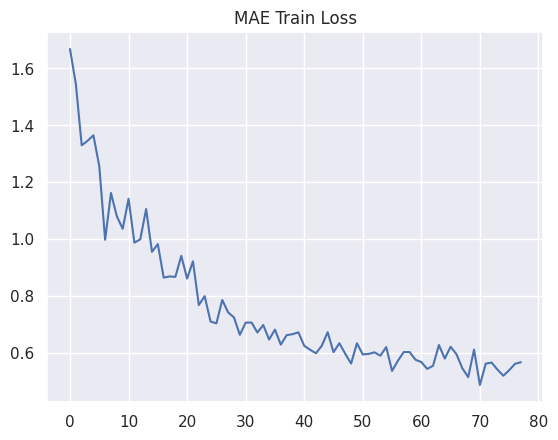

In [ ]:
# Initilize MAE model
model = MaskedAutoEncoder(
    Transformer(embedding_dim=256, n_layers=4),
    Transformer(embedding_dim=128, n_layers=2),
)
# Move the model to GPU
model.to(torch_device)
# Create optimizer

# You may want to tune these hyperparameters to get better performance
optimizer = optim.AdamW(model.parameters(), lr=1e-4, betas=(0.9, 0.95), weight_decay=0.05)

total_steps = 0
num_epochs = 20
train_logfreq = 100

losses = []

epoch_iterator = trange(num_epochs)
for epoch in epoch_iterator:
    # Train
    data_iterator = tqdm(trainloader)
    for x, y in data_iterator:
        total_steps += 1
        x = x.to(torch_device)
        image_patches = patchify(x)
        predicted_patches, mask = model(x)
        loss = torch.sum(torch.mean(torch.square(image_patches - predicted_patches), dim=-1) * mask) / mask.sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        data_iterator.set_postfix(loss=loss.item())
        if total_steps % train_logfreq == 0:
            losses.append(loss.item())

    # Periodically save model
    torch.save(model.state_dict(), os.path.join(root_folder, "mae_pretrained.pt"))

plt.plot(losses)
plt.title('MAE Train Loss')

## 4.4 用预训练 MAE 模型进行分类

使用预训练的 MAE (Masked Autoencoder) 模型进行分类任务是一种迁移学习的方法，通常适用于数据量较小的情况或者需要快速搭建模型的场景。下面是一般的步骤：

1. **准备数据集**：首先，您需要准备一个用于分类的数据集，包括训练集和测试集。确保数据集的标签是已知的，因为分类任务需要有标签的数据进行监督学习。

2. **加载预训练的 MAE 模型**：在此步骤中，您需要获取预训练好的 MAE 模型。这个预训练的 MAE 模型可以是您自己训练好的，也可以是从开源项目或者模型库中获取的预训练模型。

3. **添加分类器**：在 MAE 模型的 Decoder 部分之后添加一个分类器，可以是全连接层或者其他适合您任务的分类器。这个分类器的输出维度应该与您数据集中的类别数相匹配。

4. **训练模型**：使用训练集对整个模型进行训练，包括微调 MAE 部分和新添加的分类器。在训练过程中，通常会使用交叉熵损失函数来衡量分类器的性能，并使用反向传播算法更新模型参数。

5. **评估模型**：使用测试集对训练好的模型进行评估，计算分类准确率或者其他评估指标来衡量模型在分类任务上的性能。


通过以上步骤，您就可以利用预训练的 MAE 模型进行分类任务了。这种方法可以在数据量较小或者时间有限的情况下快速搭建一个性能良好的分类器，并且能够利用预训练模型已经学到的特征表示来提升模型的泛化能力。

### 4.4.1 代码
由于ViT具有一个class token，为了适应这一设计，在我们的MAE预训练中，我们将一个auxiliary dummy token附加到编码器输入中。该令牌将被视为线性探测和微调中训练分类器的class token。

In [ ]:
class ClassificationMAE(nn.Module):
    """A linear classifier is trained on self-supervised representations learned by MAE.
    Args:
        n_classes: number of classes
        mae: mae model
        embedding_dim: embedding dimension of mae output
        detach: if True, only the classification head is updated.
    """
    def __init__(self, n_classes, mae, embedding_dim=256, detach=False):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.mae = mae
        self.output_head = nn.Sequential(
            nn.LayerNorm(embedding_dim), nn.Linear(embedding_dim, n_classes)
        )
        """
        When self.detach=True, use linear classification, when self.detach=False,
        use full finetuning.
        """
        self.detach = detach

    def forward(self, images):
        # BEGIN YOUR CODE
        representation = self.mae.forward_encoder_representation(images)
        cls_token = representation[:,0]
        logits = self.output_head(cls_token)
        return logits
        # END YOUR CODE

### 4.4.2 测试

完成后，运行以下代码以检查您的实现。您应该看到误差小于 ``1e-4``。

In [ ]:
model = ClassificationMAE(
    10,
    MaskedAutoEncoder(
        Transformer(embedding_dim=256, n_layers=4),
        Transformer(embedding_dim=128, n_layers=2),
    )
)

model.load_state_dict(test_data['weights']['ClassificationMAE'])

check_error(
    'ClassificationMAE.forward',
    model(test_data['input']['ClassificationMAE.forward']),
    test_data['output']['ClassificationMAE.forward']
)

torch.Size([10, 65, 256])
ClassificationMAE.forward's relative error:  6.19175480096601e-05


## 4.5 MAE分类：Linear Classification

### 4.5.1 代码

线性分类器在由 MAE 学习的自监督表示上进行训练。

你可以选择调整这些超参数以获得更好的性能，也可以不做更改。

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
t

  0%|          | 0/391 [00:00<?, ?it/s]

torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
t

...

  0%|          | 0/391 [00:00<?, ?it/s]

torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
t

  0%|          | 0/391 [00:00<?, ?it/s]

torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
torch.Size([128, 65, 256])
t

Text(0.5, 1.0, 'Linear Classification Val Accuracy')

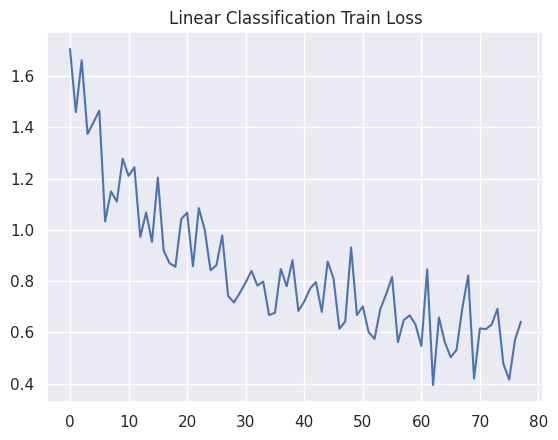

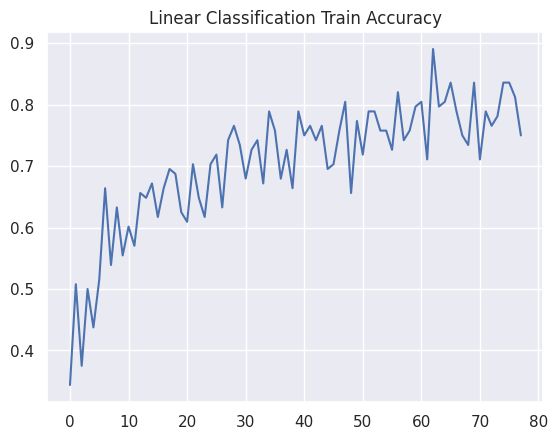

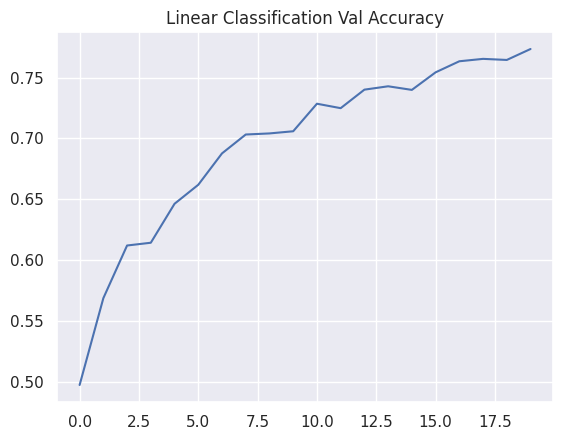

In [ ]:
mae = MaskedAutoEncoder(
    Transformer(embedding_dim=256, n_layers=4),
    Transformer(embedding_dim=128, n_layers=2),
)
mae.load_state_dict(torch.load(os.path.join(root_folder, "mae_pretrained.pt")))

# Initilize classification model; set detach=True to only update the linear classifier.
model = ClassificationMAE(10, mae, detach=True)
model.to(torch_device)

# You may want to tune these hyperparameters to get better performance
optimizer = optim.AdamW(model.parameters(), lr=1e-4, betas=(0.9, 0.95), weight_decay=1e-9)

total_steps = 0
num_epochs = 20
train_logfreq = 100
losses = []
train_acc = []
all_val_acc = []
best_val_acc = 0

epoch_iterator = trange(num_epochs)
for epoch in epoch_iterator:
    # Train
    data_iterator = tqdm(trainloader)
    for x, y in data_iterator:
        total_steps += 1
        x, y = x.to(torch_device), y.to(torch_device)
        logits = model(x)
        loss = torch.mean(F.cross_entropy(logits, y))
        accuracy = torch.mean((torch.argmax(logits, dim=-1) == y).float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        data_iterator.set_postfix(loss=loss.item(), train_acc=accuracy.item())

        if total_steps % train_logfreq == 0:
            losses.append(loss.item())
            train_acc.append(accuracy.item())

    # Validation
    val_acc = []
    model.eval()
    for x, y in testloader:
        x, y = x.to(torch_device), y.to(torch_device)
        with torch.no_grad():
          logits = model(x)
        accuracy = torch.mean((torch.argmax(logits, dim=-1) == y).float())
        val_acc.append(accuracy.item())

    model.train()

    all_val_acc.append(np.mean(val_acc))

    # Save best model
    if np.mean(val_acc) > best_val_acc:
        best_val_acc = np.mean(val_acc)

    epoch_iterator.set_postfix(val_acc=np.mean(val_acc), best_val_acc=best_val_acc)

plt.plot(losses)
plt.title('Linear Classification Train Loss')
plt.figure()
plt.plot(train_acc)
plt.title('Linear Classification Train Accuracy')
plt.figure()
plt.plot(all_val_acc)
plt.title('Linear Classification Val Accuracy')

### 4.5.2 测试

完成后，运行以下代码以检查您的实现。您应该看到准确率大于 ``30%``。

In [ ]:
check_acc(best_val_acc, threshold=0.30)

NameError: name 'check_acc' is not defined

## 4.6 MAE分类：Finetuning

### 4.6.1 代码
线性分类器和预训练的 MAE 模型会共同更新。

你可以选择调整这些超参数以获得更好的性能，也可以不做更改。

In [ ]:
mae = MaskedAutoEncoder(
    Transformer(embedding_dim=256, n_layers=4),
    Transformer(embedding_dim=128, n_layers=2),
)
mae.load_state_dict(torch.load(os.path.join(root_folder, "mae_pretrained.pt")))

# Initilize classification model; set detach=False to update both the linear classifier and pretrained MAE model.
model = ClassificationMAE(10, mae, detach=False)
model.to(torch_device)

# You may want to tune these hyperparameters to get better performance
optimizer = optim.AdamW(model.parameters(), lr=1e-4, betas=(0.9, 0.95), weight_decay=1e-9)

total_steps = 0
num_epochs = 20
train_logfreq = 100
losses = []
train_acc = []
all_val_acc = []
best_val_acc = 0

epoch_iterator = trange(num_epochs)
for epoch in epoch_iterator:
    # Train
    data_iterator = tqdm(trainloader)
    for x, y in data_iterator:
        total_steps += 1
        x, y = x.to(torch_device), y.to(torch_device)
        logits = model(x)
        loss = torch.mean(F.cross_entropy(logits, y))
        accuracy = torch.mean((torch.argmax(logits, dim=-1) == y).float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        data_iterator.set_postfix(loss=loss.item(), train_acc=accuracy.item())

        if total_steps % train_logfreq == 0:
            losses.append(loss.item())
            train_acc.append(accuracy.item())

    # Validation
    val_acc = []
    model.eval()
    for x, y in testloader:
        x, y = x.to(torch_device), y.to(torch_device)
        with torch.no_grad():
          logits = model(x)
        accuracy = torch.mean((torch.argmax(logits, dim=-1) == y).float())
        val_acc.append(accuracy.item())
    model.train()

    all_val_acc.append(np.mean(val_acc))

    # Save best model
    if np.mean(val_acc) > best_val_acc:
        best_val_acc = np.mean(val_acc)

    epoch_iterator.set_postfix(val_acc=np.mean(val_acc), best_val_acc=best_val_acc)

plt.plot(losses)
plt.title('Finetune Classification Train Loss')
plt.figure()
plt.plot(train_acc)
plt.title('Finetune Classification Train Accuracy')
plt.figure()
plt.plot(all_val_acc)
plt.title('Finetune Classification Val Accuracy')

### 4.6.2 测试

完成后，运行以下代码以检查您的实现。您应该看到准确率大于 ``70%``。

In [ ]:
check_acc(best_val_acc, threshold=0.70)

# 5 结语

恭喜你！你已经完成了第四次作业。尽管这一路历经艰辛，但是你对于 ViT 和 MAE 有了更加深刻的理解！



>本次作业负责人：郜今（助教），gaojin@sjtu.edu.cn。
最后请允许我再次强调，作业在 Canvas 上提交，只需要上传一份 ipynb 文件，请保留每个单元格的运行结果，注意时间节点。 如有任何问题，请联系[助教](https://cs7353.netlify.app/staff/)。